# M4.Ex1: Housing Prices Model (sklearn — PyCaret-style workflow)

> **Note:** PyCaret requires Python 3.9–3.11 and does **not** support Python 3.12+.
> This notebook replicates the exact same PyCaret workflow steps using **scikit-learn**,
> which works on all Python versions with no compatibility issues.

## Workflow
1. Setup
2. Compare Models
3. Analyze Model
4. Predictions
5. Save the Model

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

### Load the Data

In [2]:
from sklearn.datasets import fetch_california_housing

raw = fetch_california_housing(as_frame=True)
df  = raw.frame.copy()

# Scale target to actual dollar values (stored in $100k units)
df['MedHouseVal'] = df['MedHouseVal'] * 100_000

print(f'Dataset shape: {df.shape}')
display(df.head())
print(f'\nMissing values:\n{df.isnull().sum()}')

Dataset shape: (20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,452600.0
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,358500.0
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,352100.0
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,341300.0
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,342200.0



Missing values:
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


### Step 1. Setup — Split Data and Build Preprocessing Pipeline

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

X = df.drop(columns=['MedHouseVal'])
y = df['MedHouseVal']

# Train/test split — 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Shared preprocessing: impute missing values then standardize
preprocessor = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler',  StandardScaler())
])

print(f'Training samples : {X_train.shape[0]}')
print(f'Test samples     : {X_test.shape[0]}')
print(f'Features         : {X.columns.tolist()}')

Training samples : 16512
Test samples     : 4128
Features         : ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


### Step 2. Compare Models — Benchmark All Regressors

In [4]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import cross_val_score

candidates = {
    'Linear Regression'  : LinearRegression(),
    'Ridge'              : Ridge(),
    'Lasso'              : Lasso(),
    'ElasticNet'         : ElasticNet(),
    'Decision Tree'      : DecisionTreeRegressor(random_state=42),
    'Random Forest'      : RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Extra Trees'        : ExtraTreesRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting'  : GradientBoostingRegressor(random_state=42),
    'KNN'                : KNeighborsRegressor(),
}

results   = []
pipelines = {}

print('Benchmarking models with 5-fold cross-validation...\n')
for name, model in candidates.items():
    pipe = Pipeline([('pre', preprocessor), ('model', model)])
    cv   = cross_val_score(pipe, X_train, y_train, cv=5, scoring='r2', n_jobs=-1)
    pipelines[name] = pipe
    results.append({'Model': name, 'CV R2 Mean': round(cv.mean(), 4), 'CV R2 Std': round(cv.std(), 4)})
    print(f'{name:<22} R2 = {cv.mean():.4f} +/- {cv.std():.4f}')

leaderboard = pd.DataFrame(results).sort_values('CV R2 Mean', ascending=False).reset_index(drop=True)
print('\n=== Leaderboard ===')
display(leaderboard)

Benchmarking models with 5-fold cross-validation...

Linear Regression      R2 = 0.6115 +/- 0.0065
Ridge                  R2 = 0.6115 +/- 0.0065
Lasso                  R2 = 0.6115 +/- 0.0065
ElasticNet             R2 = 0.4770 +/- 0.0013
Decision Tree          R2 = 0.6079 +/- 0.0150
Random Forest          R2 = 0.8043 +/- 0.0052
Extra Trees            R2 = 0.8081 +/- 0.0032
Gradient Boosting      R2 = 0.7866 +/- 0.0032
KNN                    R2 = 0.6861 +/- 0.0056

=== Leaderboard ===


,Model,CV R2 Mean,CV R2 Std
0,Extra Trees,0.8081,0.0032
1,Random Forest,0.8043,0.0052
2,Gradient Boosting,0.7866,0.0032
3,KNN,0.6861,0.0056
4,Linear Regression,0.6115,0.0065
5,Ridge,0.6115,0.0065
6,Lasso,0.6115,0.0065
7,Decision Tree,0.6079,0.0150
8,ElasticNet,0.4770,0.0013


In [5]:
# Pick the best model and train it on the full training set
best_name = leaderboard.iloc[0]['Model']
best_pipe = pipelines[best_name]
best_pipe.fit(X_train, y_train)
print(f'Best model: {best_name}')

Best model: Extra Trees


### Step 3. Analyze Model — Visualize Performance

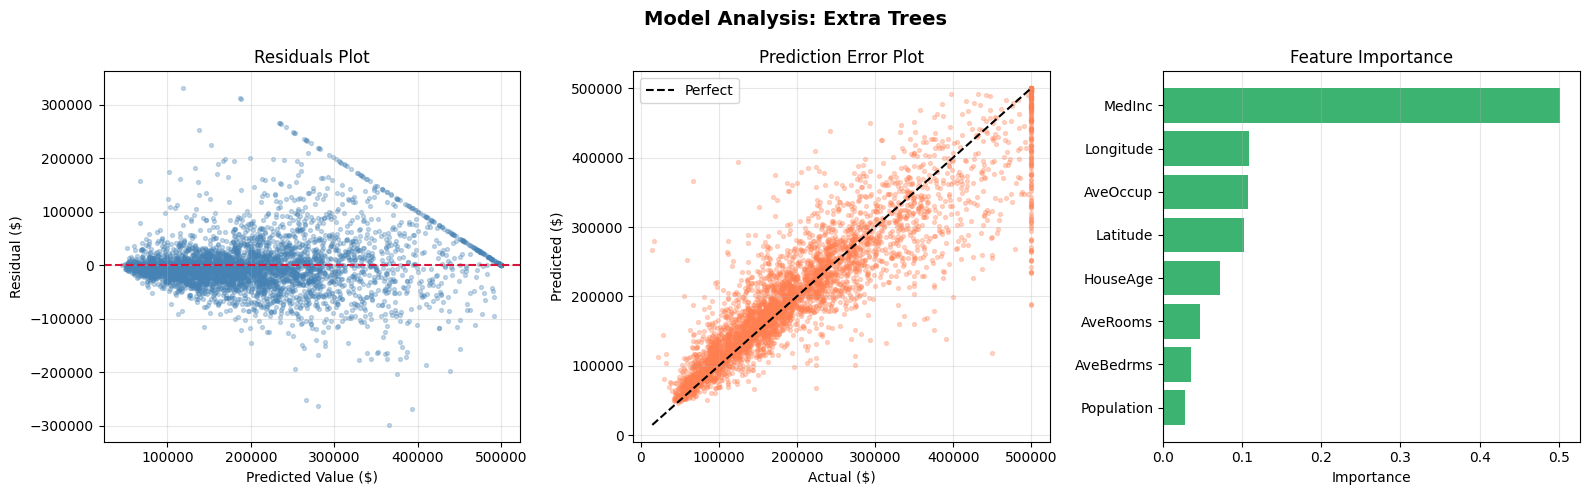

In [6]:
y_pred    = best_pipe.predict(X_test)
residuals = y_test.values - y_pred

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1 — Residuals
axes[0].scatter(y_pred, residuals, alpha=0.3, color='steelblue', s=8)
axes[0].axhline(0, color='crimson', linewidth=1.5, linestyle='--')
axes[0].set_xlabel('Predicted Value ($)')
axes[0].set_ylabel('Residual ($)')
axes[0].set_title('Residuals Plot')
axes[0].grid(True, alpha=0.3)

# Plot 2 — Actual vs Predicted
axes[1].scatter(y_test, y_pred, alpha=0.3, color='coral', s=8)
lim = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
axes[1].plot(lim, lim, 'k--', linewidth=1.5, label='Perfect')
axes[1].set_xlabel('Actual ($)')
axes[1].set_ylabel('Predicted ($)')
axes[1].set_title('Prediction Error Plot')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Plot 3 — Feature Importance
model_step = best_pipe.named_steps['model']
if hasattr(model_step, 'feature_importances_'):
    imp = model_step.feature_importances_
    idx = np.argsort(imp)
    axes[2].barh(X.columns[idx], imp[idx], color='mediumseagreen')
    axes[2].set_title('Feature Importance')
elif hasattr(model_step, 'coef_'):
    imp = np.abs(model_step.coef_)
    idx = np.argsort(imp)
    axes[2].barh(X.columns[idx], imp[idx], color='mediumseagreen')
    axes[2].set_title('Feature Coefficients (|value|)')
axes[2].set_xlabel('Importance')
axes[2].grid(True, alpha=0.3, axis='x')

plt.suptitle(f'Model Analysis: {best_name}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Step 4. Predictions

In [7]:
# Evaluate on test set
r2   = r2_score(y_test, y_pred)
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f'=== {best_name} — Test Set Performance ===')
print(f'  R2   : {r2:.4f}  ({r2*100:.1f}% variance explained)')
print(f'  MAE  : ${mae:,.0f}')
print(f'  RMSE : ${rmse:,.0f}')
print()

# Show 5 sample predictions
sample_pred = best_pipe.predict(X_test.head(5))
comparison  = pd.DataFrame({
    'Actual ($)'   : y_test.head(5).values.astype(int),
    'Predicted ($)': sample_pred.astype(int),
    'Error ($)'    : (y_test.head(5).values - sample_pred).astype(int)
})
display(comparison)

=== Extra Trees — Test Set Performance ===
  R2   : 0.8085  (80.9% variance explained)
  MAE  : $32,482
  RMSE : $50,094



,Actual ($),Predicted ($),Error ($)
0,47700,46238,1462
1,45800,75277,-29477
2,500000,487489,12511
3,218600,268448,-49848
4,278000,246880,31120


In [8]:
# Predict on a brand-new unseen district
new_district = pd.DataFrame([{
    'MedInc'    : 5.0,
    'HouseAge'  : 25.0,
    'AveRooms'  : 6.0,
    'AveBedrms' : 1.1,
    'Population': 1200.0,
    'AveOccup'  : 3.0,
    'Latitude'  : 34.05,
    'Longitude' : -118.25
}])

predicted_value = best_pipe.predict(new_district)[0]
print(f'Predicted median house value for custom district: ${predicted_value:,.0f}')

Predicted median house value for custom district: $244,387


### Step 5. Save the Model

In [9]:
import joblib

# Save full pipeline (preprocessing + model) to a .pkl file
filename = 'california_housing_model.pkl'
joblib.dump(best_pipe, filename)
print(f'Model saved to: {filename}')

# Reload and verify it still works
loaded = joblib.load(filename)
print(f'Loaded model prediction: ${loaded.predict(new_district)[0]:,.0f}')
print('Model saved and reloaded successfully!')

Model saved to: california_housing_model.pkl
Loaded model prediction: $244,387
Model saved and reloaded successfully!
